## Generate Plots for all stations in MESH_output_streamflow.csv 

## Hydrograph plotting from the MESH_output_streamflow.csv files

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ----------------------------
# METRICS
# ----------------------------
def compute_metrics(obs, sim):
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    obs = obs[mask]
    sim = sim[mask]

    if len(obs) == 0:
        return np.nan, np.nan, np.nan

    nse = 1 - np.sum((sim - obs)**2) / np.sum((obs - np.mean(obs))**2)

    r = np.corrcoef(obs, sim)[0, 1]
    alpha = np.std(sim) / np.std(obs)
    beta = np.mean(sim) / np.mean(obs)
    kge = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

    pbias = 100 * (np.sum(sim - obs) / np.sum(obs))

    return nse, kge, pbias

# ----------------------------
# CLIMATOLOGY
# ----------------------------
def daily_stats(data):
    data = data[~((data.index.month == 2) & (data.index.day == 29))]
    grouped = data.groupby(data.index.dayofyear)

    mean = grouped.mean()
    p10 = grouped.quantile(0.1)
    p90 = grouped.quantile(0.9)

    return mean, p10, p90

# ----------------------------
# MAIN FUNCTION
# ----------------------------
def plot_multi_station(file_path,
                       spinup_end,
                       calib_end,
                       save=True,
                       out_dir="plots"):

    # ---- LOAD ----
    if file_path.endswith(".xlsx"):
        df = pd.read_excel(file_path)
    else:
        df = pd.read_csv(file_path)

    # ---- CLEAN COLUMN NAMES ----
    df.columns = df.columns.str.strip()

    # ---- DATE ----
    df["date"] = pd.to_datetime(df["YEAR"], format="%Y") + \
                 pd.to_timedelta(df["JDAY"] - 1, unit="D")

    df.set_index("date", inplace=True)
    df.sort_index(inplace=True)

    # ---- FIND STATIONS ----
    obs_cols = [c for c in df.columns if c.startswith("QOMEAS_")]
    sim_cols = [c for c in df.columns if c.startswith("QOSIM_")]

    # Extract station IDs
    station_ids = [c.replace("QOMEAS_", "") for c in obs_cols]

    print(f"Stations found: {station_ids}")

    os.makedirs(out_dir, exist_ok=True)

    # ---- LOOP OVER STATIONS ----
    for st in station_ids:

        obs_col = f"QOMEAS_{st}"
        sim_col = f"QOSIM_{st}"

        if sim_col not in df.columns:
            print(f"⚠️ Missing simulation for {st}, skipping...")
            continue

        print(f"Processing station: {st}")

        data = df.copy()

        # Clean missing values
        data["observed"] = data[obs_col].replace(-1, np.nan)
        data["simulated"] = data[sim_col].replace(-1, np.nan)

        # ---- PERIOD SPLIT ----
        spinup = data[:spinup_end]
        calib = data[spinup_end:calib_end].iloc[1:]
        valid = data[calib_end:].iloc[1:]

        periods = {
            "Spin-up": spinup,
            "Calibration": calib,
            "Verification": valid
        }

        # ---- PLOT ----
        fig, axes = plt.subplots(3, 2, figsize=(15, 11),
                                 gridspec_kw={'width_ratios': [3, 1]})

        for i, (name, d) in enumerate(periods.items()):

            nse, kge, pbias = compute_metrics(
                d["observed"].values,
                d["simulated"].values
            )

            # Hydrograph
            ax = axes[i, 0]
            ax.plot(d.index, d["observed"],
                    color="black", linewidth=2.2, label="Observed")

            ax.plot(d.index, d["simulated"],
                    color="red", linestyle="-", linewidth=1.2, label="Simulated")

            ax.set_title(f"{name} - Station {st}")
            ax.set_ylabel("Flow")
            ax.grid(True)

            ax.text(0.01, 0.95,
                    f"NSE={nse:.2f}\nKGE={kge:.2f}\nBias={pbias:.1f}%",
                    transform=ax.transAxes,
                    verticalalignment='top',
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

            if i == 0:
                ax.legend()

            # Climatology
            ax2 = axes[i, 1]
            mean, p10, p90 = daily_stats(d)
            days = np.arange(1, len(mean) + 1)

            ax2.plot(days, mean["observed"], color="black", linewidth=2)
            ax2.fill_between(days, p10["observed"], p90["observed"],
                             color="gray", alpha=0.3)

            ax2.plot(days, mean["simulated"],
                     color="red", linestyle="-", linewidth=1.5)
            ax2.fill_between(days, p10["simulated"], p90["simulated"],
                             color="red", alpha=0.15)

            ax2.set_title("Daily Mean (P10–P90)")
            ax2.set_xlabel("Day of Year")
            ax2.grid(True)

        plt.tight_layout()

        # ---- SAVE ----
        if save:
            plt.savefig(f"{out_dir}/hydrograph_{st}.png", dpi=300)
            plt.close()
        else:
            plt.show()

In [ ]:
# Call the ploting function with the following inputs: validation period is determined from the rest of the time period
plot_multi_station(
    "Defau_MESH_output_streamflow.csv",
    spinup_end="1999-09-30",
    calib_end="2010-01-30",
    save=True
)

### Streamflow Completeness Plot: Completeness Assessment of Streamflow Data from MESH_input_streamflow.tb0

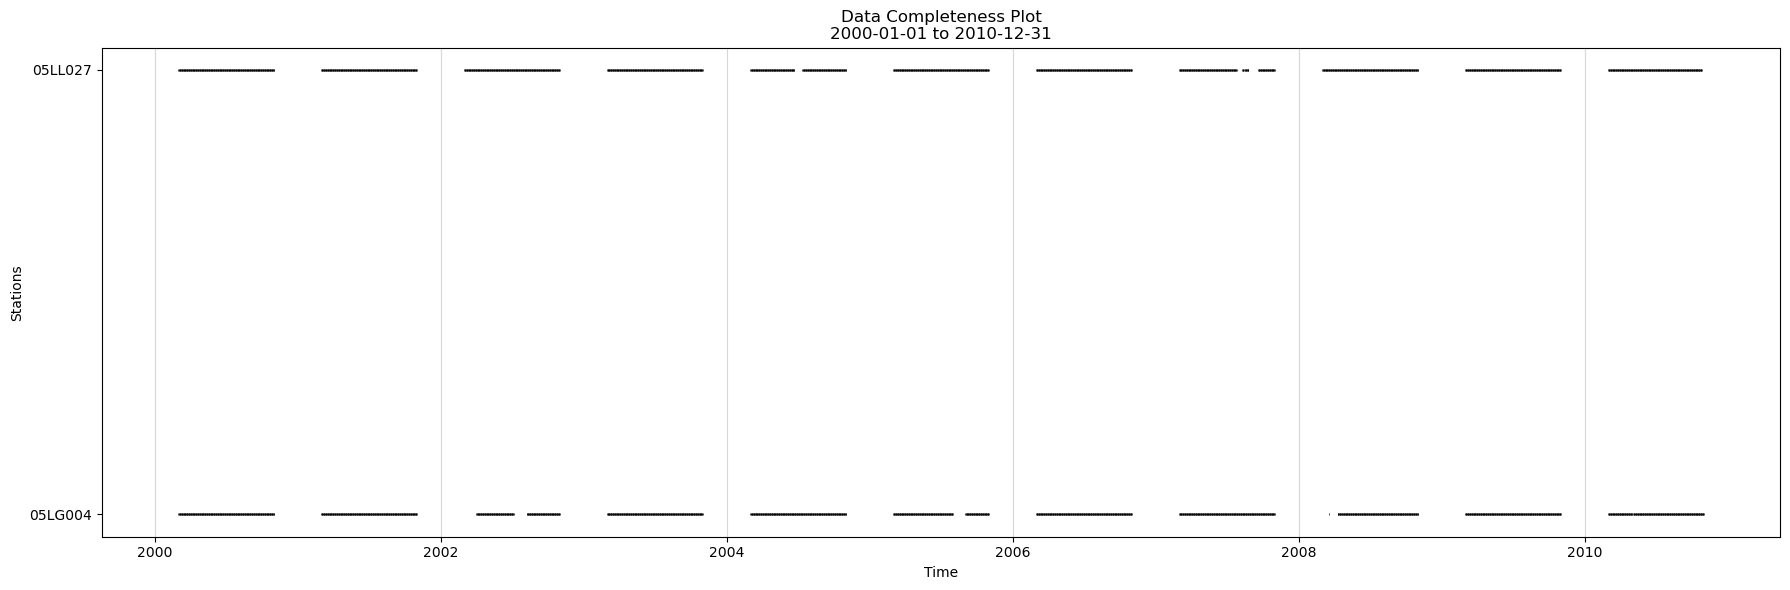

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import numpy as np

# ============================================================
# USER SETTINGS
# ============================================================

file_path = "MESH_input_streamflow.tb0"

# Select stations (None = all stations)
selected_stations = None #[
#    "02YS003",
#    "04FA001",
#    "14185000"
#]

# Select period
start_period = "2000-01-01"
end_period   = "2010-12-31"

# Missing value
missing_value = -1

# ============================================================
# READ FILE
# ============================================================

with open(file_path, "r") as f:
    lines = f.readlines()

# ------------------------------------------------------------
# Extract metadata
# ------------------------------------------------------------

start_time = None
delta_t_hours = 24
station_names = []
data_start_idx = None

for i, line in enumerate(lines):

    line = line.strip()

    if line.startswith(":StartTime"):

        parts = line.split()

        start_time = datetime.strptime(
            parts[1] + " " + parts[2],
            "%Y/%m/%d %H:%M:%S.%f"
        )

    elif line.startswith(":DeltaT"):

        delta_t_hours = int(line.split()[1])

    elif line.startswith(":ColumnName"):

        station_names = line.split()[1:]

    elif line.lower() == ":endheader":

        data_start_idx = i + 1
        break

# ============================================================
# READ DATA
# ============================================================

data = []

for line in lines[data_start_idx:]:

    line = line.strip()

    if not line:
        continue

    values = [float(v) for v in line.split()]
    data.append(values)

# Create dataframe
df = pd.DataFrame(data, columns=station_names)

# ============================================================
# CREATE TIME INDEX
# ============================================================

dates = [
    start_time + timedelta(hours=delta_t_hours * i)
    for i in range(len(df))
]

df.index = pd.to_datetime(dates)

# ============================================================
# FILTER TIME PERIOD
# ============================================================

df = df.loc[start_period:end_period]

# ============================================================
# FILTER STATIONS
# ============================================================

if selected_stations is not None:

    available = [s for s in selected_stations if s in df.columns]

    if len(available) == 0:
        raise ValueError("Selected stations not found.")

    df = df[available]

# ============================================================
# COMPLETENESS PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(18, 6))

# Plot one horizontal line per station
for i, station in enumerate(df.columns):

    # Get valid data locations
    valid = df[station] != missing_value

    # Create y values
    y = np.full(valid.sum(), i)

    # Plot only valid periods
    ax.plot(
        df.index[valid],
        y,
        linestyle='None',
        marker='|',
        markersize=2,
        markeredgewidth=0.5,
        color='black'
    )

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

ax.set_yticks(range(len(df.columns)))
ax.set_yticklabels(df.columns)

ax.set_xlabel("Time")
ax.set_ylabel("Stations")

ax.set_title(
    f"Data Completeness Plot\n"
    f"{start_period} to {end_period}"
)

ax.grid(True, axis='x', linestyle='-', alpha=0.5)

plt.tight_layout()
plt.show()